In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import h5py, os, tqdm, glob, scipy
os.environ['XLA_PYTHON_CLIENT_MEM_FRACTION'] = '0.49'
import numpy as np
import matplotlib.pyplot as plt
from functools import partial

import jax
import jax.numpy as jnp
import jax_cosmo as jc

import optax
from optax.losses import huber_loss
from flax import nnx
import orbax.checkpoint as ocp
import jraph

import diffrax
from diffrax import diffeqsolve, ODETerm, LeapfrogMidpoint, PIDController, SaveAt, ConstantStepSize

import jaxpm
from jaxpm.painting import cic_paint, cic_read, compensate_cic
from jaxpm.kernels import fftk, gradient_kernel, invlaplace_kernel, longrange_kernel, invnabla_kernel
from jaxpm.utils import power_spectrum, cross_correlation_coefficients
from jaxpm.nn import MLP, CNN, HybridNet, AttentionGNN
from jaxpm import camels, plotting, hpm, nn, graph

# print(jax.devices("gpu"))
print(jax.default_backend())

gpu


# configuration

In [27]:
parts_per_dim = 64
mesh_per_dim = parts_per_dim
mesh_shape = [mesh_per_dim] * 3
box_size = [float(mesh_per_dim)] * 3

# i_snapshots = [-2,-1]
i_snapshots = range(1, 33+4, 8)
# i_snapshots = range(1, 33+4, 4)
# i_snapshots = range(1, 33+2, 2)
# i_snapshots = range(1, 33+1, 1)
# i_snapshots = range(0, 8, 1)
# i_snapshots = np.arange(-4, 0, dtype=int)
# i_snapshots = np.arange(10, 20, dtype=int)

# CAMELS

In [28]:
out_dict = camels.load_CV_snapshots(
    "CV_0",
    mesh_per_dim,
    parts_per_dim,
    i_snapshots=i_snapshots,
    return_hydro=True,
)

cosmo = out_dict["cosmo"]
scales = out_dict["scales"]

dm_poss = out_dict["dm_poss"]
dm_vels = out_dict["dm_vels"]

gas_poss = out_dict["gas_poss"]
gas_vels = out_dict["gas_vels"]

Found matching catalogs
Using snapshots ['/cluster/work/refregier/athomsen/flatiron/CAMELS/Sims/SIMBA/CV/CV_0/snapshot_018.hdf5', '/cluster/work/refregier/athomsen/flatiron/CAMELS/Sims/SIMBA/CV/CV_0/snapshot_042.hdf5', '/cluster/work/refregier/athomsen/flatiron/CAMELS/Sims/SIMBA/CV/CV_0/snapshot_058.hdf5', '/cluster/work/refregier/athomsen/flatiron/CAMELS/Sims/SIMBA/CV/CV_0/snapshot_074.hdf5', '/cluster/work/refregier/athomsen/flatiron/CAMELS/Sims/SIMBA/CV/CV_0/snapshot_090.hdf5']
Selecting 262144 dark matter (deterministic)
Selecting 262144 gas particles (random)


finding unique gas particle indices:  20%|██        | 1/5 [00:01<00:05,  1.46s/it]

Found 368 duplicate gas particle IDs


finding unique gas particle indices:  40%|████      | 2/5 [00:07<00:11,  3.94s/it]

Found 4088 duplicate gas particle IDs


...

Found 14787 duplicate gas particle IDs


finding unique gas particle indices: 100%|██████████| 5/5 [00:24<00:00,  4.83s/it]


There are 15915410 (94.86%) gas particles that exist in all snapshots


loading snapshots: 100%|██████████| 5/5 [00:54<00:00, 10.93s/it]

Could not stack h_poss
Could not stack h_masss
Could not stack h_lens
Could not stack h_ids


In [5]:
# vali_dict = camels.load_CV_snapshots(
#     "CV_1",
#     mesh_per_dim,
#     parts_per_dim,
#     i_snapshots=i_snapshots,
#     return_hydro=True,
# )

In [6]:
vcic_paint = jax.vmap(cic_paint, in_axes=(None,0,None))
vcic_read = jax.vmap(cic_read, in_axes=(0,0))

In [7]:
@nnx.jit(static_argnames=("loss_fn",))
def train_step(model, optimizer, loss_fn):
    loss, grads = nnx.value_and_grad(loss_fn)(model)
    optimizer.update(grads)

    return loss

losses = []

In [8]:
def solve_ode_diffrax(model, architecture):    
    res = diffeqsolve(
            terms=ODETerm(hpm.get_hpm_network_ode_fn(mesh_per_dim, cosmo, dm_model=None, gas_model=model, gas_architecture=architecture)),
            solver=LeapfrogMidpoint(),
            t0=scales[0],
            t1=scales[-1],
            dt0=0.01,
            # dt0=0.04,
            # dt0=0.005,
            y0=(dm_poss[0], dm_vels[0], gas_poss[0], gas_vels[0]),
            saveat=SaveAt(ts=scales),
            # max_steps=100,
            stepsize_controller=ConstantStepSize(),
        )
    res = res.ys

    return res

# loss

### CAMELS ground truth

In [9]:
# per-particle reference
ref_pos = jnp.stack(gas_poss, axis=0)
ref_vel = jnp.stack(gas_vels, axis=0)

# field-level reference
gas_mass = cosmo.Omega_b / (cosmo.Omega_b + cosmo.Omega_c)
ref_rho = vcic_paint(jnp.zeros(mesh_shape), gas_poss, gas_mass)

# power spectrum reference
vpower_spectrum = jax.vmap(
    lambda fields: 
        power_spectrum(
            compensate_cic(fields),
            boxsize=np.array([25.0] * 3),
            kmin=np.pi / 25.0,
            dk=2 * np.pi / 25.0,
        )
)
_, ref_cls = vpower_spectrum(ref_rho)

vcross_correlation_separate = jax.vmap(
    lambda field_a, field_b:
        cross_correlation_coefficients(
            compensate_cic(field_a),
            compensate_cic(field_b),
            boxsize=np.array([25.0] * 3),
            kmin=np.pi / 25.0,
            dk=2 * np.pi / 25.0,
        )
)
vcross_correlation = lambda rhos: vcross_correlation_separate(rhos, ref_rho)

In [10]:
# res = solve_ode_diffrax(model, architecture)
# gas_poss = res[2]
# res_rho = vcic_paint(jnp.zeros(mesh_shape), gas_poss, gas_mass)

# kbins, res_cross = vcross_correlation(res_rho)

In [11]:
# k = kbins[0]
# k_min = k[0]
# k_cutoff = k[int(0.2*len(k))]
# k_weights = jnp.exp(-(k - k[0]) / k_cutoff)

# plt.plot(k, k_weights)
# # plt.ylim(0,1)
# plt.xscale("linear")
# plt.yscale("log")
# plt.show()

# plt.plot(k, res_cross[-1], label="original")
# plt.plot(k, k_weights * res_cross[-1], label="weighted")
# plt.xscale("linear")
# plt.yscale("log")
# plt.legend()
# plt.show()

### particle-level

In [12]:
def particle_loss_fn(model, architecture, huber=False, pos_dead_zone=False):
    res = solve_ode_diffrax(model, architecture)
    gas_poss = res[2]
    gas_vels = res[3]

    delta_pos = ((gas_poss - ref_pos + mesh_per_dim // 2) % mesh_per_dim) - mesh_per_dim // 2
    if huber:
        pos_loss = jnp.sum(huber_loss(delta_pos), axis=-1)
    else:
        pos_loss = jnp.sum(delta_pos**2, axis=-1)
    if pos_dead_zone:
        pos_loss = jnp.where(jnp.sqrt(pos_loss) < 1/mesh_per_dim, 0.0, pos_loss)

    # pos_loss /= scales[:, jnp.newaxis, jnp.newaxis]**2
    
    pos_loss = jnp.mean(pos_loss)
    # print(f"pos_loss = {pos_loss:.4f}")
    print("pos_loss = ", pos_loss)

    # vel_loss = jnp.sum(((gas_vels - ref_vel) / (jnp.sqrt(ref_vel_disp[...,np.newaxis]) + 1e-5))**2, axis=-1)
    vel_loss = jnp.sum((gas_vels - ref_vel)**2, axis=-1)
    vel_loss = jnp.mean(vel_loss)
    print("vel_loss = ", vel_loss)
    
    res_rho = vcic_paint(jnp.zeros(mesh_shape), gas_poss, gas_mass)
    kbins, res_cls = vpower_spectrum(res_rho)

    k = kbins[0]
    k_min, k_cutoff = k[0], k[int(0.2*len(k))]
    k_weights = jnp.expand_dims(jnp.exp(-(k - k_min) / k_cutoff), 0)

    cl_loss = jnp.sum(((res_cls/ref_cls - 1)*k_weights)**2, axis=-1)
    cl_loss = jnp.mean(cl_loss)

    # cl_loss = jnp.mean(jnp.sum((res_cls/ref_cls - 1)**2, axis=-1))
    cl_fac = 0.1
    # print(f"cl_loss = {cl_fac * cl_loss:.4f}")
    print("cl_loss = ", cl_fac * cl_loss)

    # _, res_cross = vcross_correlation(res_rho)
    # cross_loss = jnp.sum(((res_cross/jnp.sqrt(ref_cls * res_cls) - 1) * k_weights)**2)
    # # cross_loss = jnp.sum((res_cross/jnp.sqrt(ref_cls * res_cls) - 1)**2)
    # cross_loss = jnp.mean(cross_loss)

    # dm_force, gas_force, d_gas_latent = jax.vmap(
    #     lambda scale, dm_p, gas_p, gas_v, gas_l: hpm.hpm_forces(
    #         mesh_per_dim, cosmo, scale, dm_p, gas_p, 
    #         gas_model=model, gas_architecture=architecture,
    #         gas_vel=gas_v, gas_latent=gas_l,
    #     ),
    #     in_axes=(0, 0, 0, 0, 0)
    # )(scales, res[0], res[2], res[3], res[4])  

    # corr_matrix = jax.vmap(lambda array: jnp.corrcoef(array, rowvar=False), in_axes=0)(d_gas_latent)
    # latent_loss = jnp.square(corr_matrix - jnp.expand_dims(jnp.eye(corr_matrix.shape[1]), axis=0))
    # latent_loss = jnp.mean(latent_loss)
    # print(latent_loss)
    
    # cross_loss = jnp.mean(jnp.sum((res_cross/jnp.sqrt(ref_cls * res_cls) - 1)**2, axis=-1))
    # print(cross_loss)

    return pos_loss + cl_loss + vel_loss
    # return pos_loss + cl_fac * cl_loss
    # return pos_loss
    # return pos_loss + 0.01 * vel_loss + 0.1 * cl_loss
    # return pos_loss + 0.1 * cl_loss + 0.1 * cross_loss + latent_loss
    # return cross_loss
    # return pos_loss + cl_loss + cross_loss

In [13]:
particle_loss_fn(model, architecture)

NameError: name 'model' is not defined

# architecture

### MLP

In [14]:
model = MLP(
    d_in=5,
    d_out=1, 
    d_hidden=64, 
    n_hidden=4, 
    rngs=nnx.Rngs(0)
)

untrained_model = MLP(
    d_in=5,
    d_out=1, 
    d_hidden=64, 
    n_hidden=4, 
    rngs=nnx.Rngs(0)
)

architecture = "mlp"

### MLP + CNN

In [15]:
# mlp = MLP(
#     d_in=5,
#     d_out=8, 
#     d_hidden=64, 
#     n_hidden=4, 
#     rngs=nnx.Rngs(0)
# )

# cnn = CNN(
#     d_in=4, 
#     d_out=8,
#     d_hidden=16,
#     n_hidden=1,
#     kernel_size=(3, 3, 3),
#     strides=1,
#     rngs=nnx.Rngs(0)
# )

# model = HybridNet(
#     mlp,
#     cnn,
#     d_out=1, 
#     rngs=nnx.Rngs(0)
# )

# architecture = "mlp+cnn"

# training

In [16]:
total_steps = 200
# learning_rate = 1e-4
learning_rate = optax.cosine_decay_schedule(
    init_value=1e-3, 
    decay_steps=total_steps, 
    alpha=0.1
)
clip_norm = 1

optimizer = nnx.Optimizer(
    model,
    optax.chain(
        optax.clip_by_global_norm(clip_norm),
        optax.adam(learning_rate)
    )
)

losses = []
loss_fn = lambda model: particle_loss_fn(model, architecture)
# loss_fn = lambda model: field_loss_fn(model, architecture)

  0%|          | 0/200 [00:00<?, ?it/s]

dark matter and gas
Using learned pressure force
No latent variable
dark matter and gas
Using learned pressure force
No latent variable
dark matter and gas
Using learned pressure force
No latent variable
pos_loss =  Traced<ShapedArray(float32[])>with<JVPTrace(level=3/0)> with
  primal = Traced<ShapedArray(float32[])>with<DynamicJaxprTrace(level=1/0)>
  tangent = Traced<ShapedArray(float32[])>with<JaxprTrace(level=2/0)> with
    pval = (ShapedArray(float32[]), None)
    recipe = JaxprEqnRecipe(eqn_id=<object object at 0x14d91a76b0d0>, in_tracers=(Traced<ShapedArray(float32[4,262144]):JaxprTrace(level=2/0)>,), out_tracer_refs=[<weakref at 0x14d91ad8f560; to 'JaxprTracer' at 0x14d91ad8fab0>], out_avals=[ShapedArray(float32[])], primitive=pjit, params={'jaxpr': { lambda ; a:f32[4,262144]. let
    b:f32[] = reduce_sum[axes=(0, 1)] a
    c:f32[] = div b 1048576.0
  in (c,) }, 'in_shardings': (UnspecifiedValue,), 'out_shardings': (UnspecifiedValue,), 'in_layouts': (None,), 'out_layouts': (Non

2025-03-21 17:40:16.032482: E external/xla/xla/service/slow_operation_alarm.cc:65] Constant folding an instruction is taking > 1s:

  %negate.61 = f32[4,262144,3]{2,1,0} negate(f32[4,262144,3]{2,1,0} %constant.212)

This isn't necessarily a bug; constant-folding is inherently a trade-off between compilation time and speed at runtime. XLA has some guards that attempt to keep constant folding from taking too long, but fundamentally you'll always be able to come up with an input program that takes a long time.

If you'd like to file a bug, run with envvar XLA_FLAGS=--xla_dump_to=/tmp/foo and attach the results.
2025-03-21 17:40:17.300682: E external/xla/xla/service/slow_operation_alarm.cc:133] The operation took 2.268291299s
Constant folding an instruction is taking > 1s:

  %negate.61 = f32[4,262144,3]{2,1,0} negate(f32[4,262144,3]{2,1,0} %constant.212)

This isn't necessarily a bug; constant-folding is inherently a trade-off between compilation time and speed at runtime. XLA has some gu

[None]

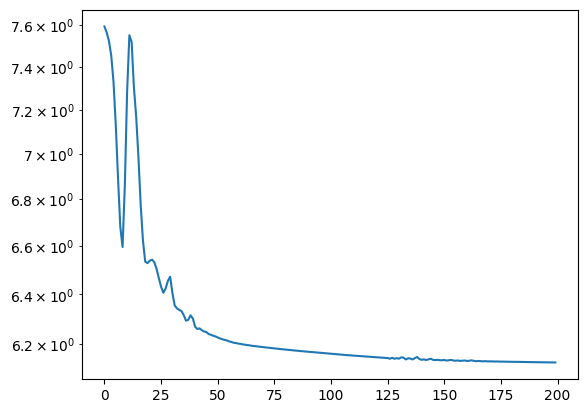

In [17]:
for i in (pbar := tqdm.tqdm(range(total_steps))):  
    loss = train_step(model, optimizer, loss_fn)

    losses.append(loss)
    pbar.set_description(f"Loss: {loss:.4f}")

fig, ax = plt.subplots()
ax.plot(losses)
ax.set(yscale="log")

# run the simulation

In [18]:
og_ode = hpm.get_hpm_network_ode_fn(mesh_per_dim, cosmo)

og_res = diffeqsolve(
        terms=ODETerm(og_ode),
        solver=LeapfrogMidpoint(),
        t0=scales[0],
        t1=scales[-1],
        dt0=0.01,
        y0=(dm_poss[0], dm_vels[0], gas_poss[0], gas_vels[0]),
        saveat=SaveAt(ts=scales),
        max_steps=100,
        stepsize_controller=ConstantStepSize(),
)

og_dm_poss, og_dm_vels, og_gas_poss, og_gas_vels = og_res.ys

dark matter and gas
dark matter and gas
dark matter and gas


In [19]:
nn_ode = hpm.get_hpm_network_ode_fn(mesh_per_dim, cosmo, gas_model=model, gas_architecture=architecture)

nn_res = diffeqsolve(
        terms=ODETerm(nn_ode),
        solver=LeapfrogMidpoint(),
        t0=scales[0],
        t1=scales[-1],
        dt0=0.01,
        y0=(dm_poss[0], dm_vels[0], gas_poss[0], gas_vels[0]),
        saveat=SaveAt(ts=scales),
        max_steps=100,
        stepsize_controller=ConstantStepSize(),
)

nn_dm_poss, nn_dm_vels, nn_gas_poss, nn_gas_vels = nn_res.ys

dark matter and gas
Using learned pressure force
No latent variable
dark matter and gas
Using learned pressure force
No latent variable
dark matter and gas
Using learned pressure force
No latent variable


100%|██████████| 4/4 [00:02<00:00,  1.59it/s]


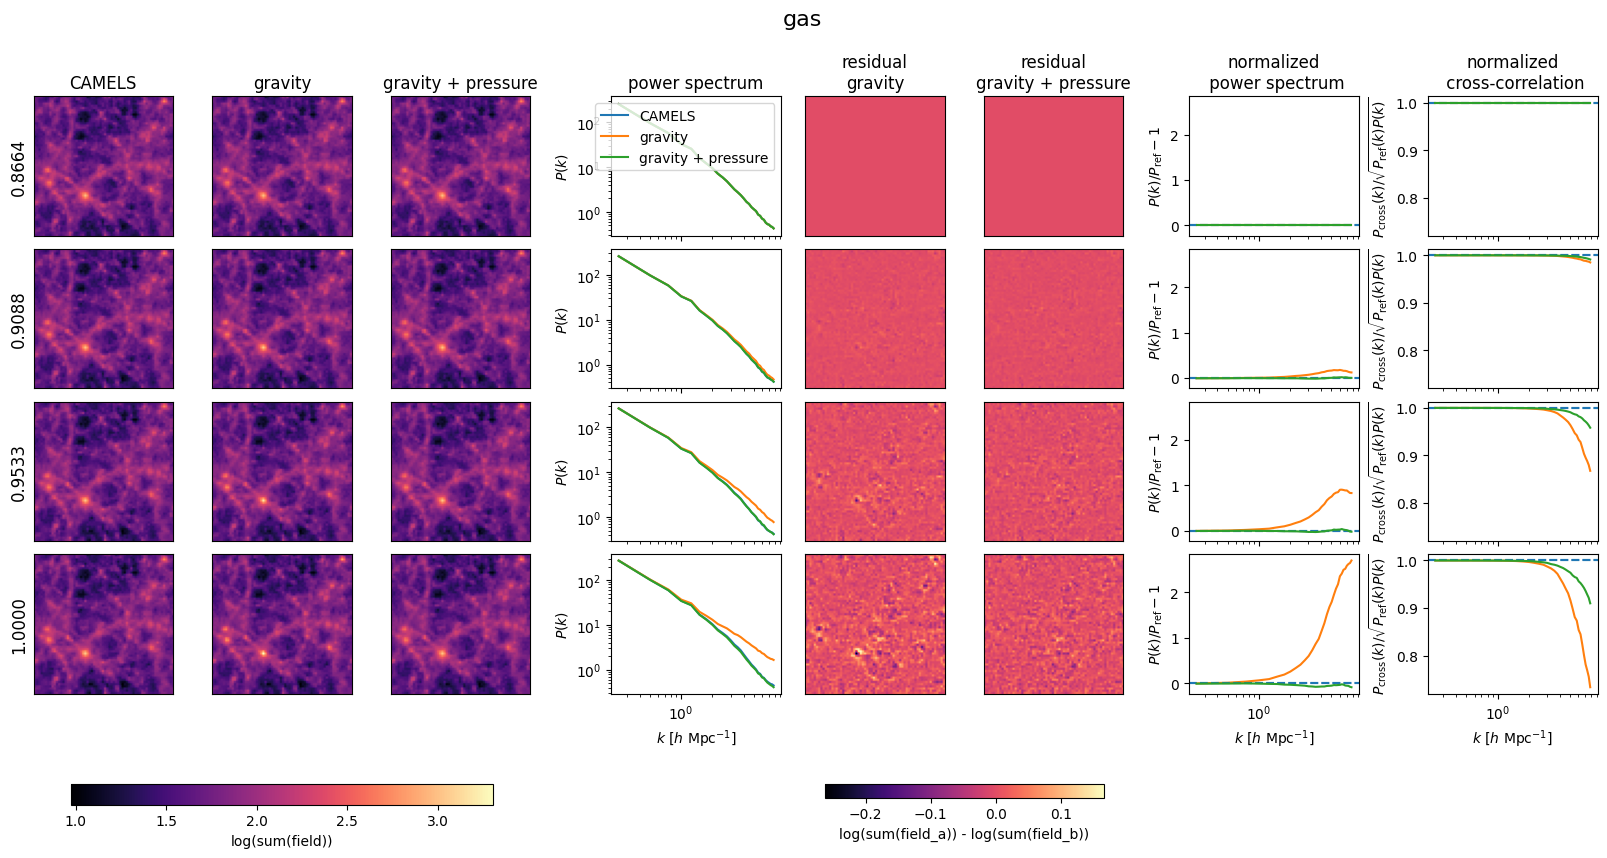

In [20]:
with jax.default_device(jax.devices("cpu")[0]):
    plotting.compare_particle_evolution(
        mesh_shape, 
        scales, 
        jnp.stack([gas_poss, og_gas_poss, nn_gas_poss], axis=0), 
        title="gas",
        col_titles=["CAMELS", "gravity", "gravity + pressure"],
        include_pk=True,
        include_reference=True,
        out_dir=f"plots/particle_evolution_i={i_snapshots},dt0=0.005",
    )

### test

In [21]:
def plot_loss_of_scale(gas_poss, gas_vels, title="", out_dir=None):
    delta_pos = ((gas_poss - ref_pos + mesh_per_dim // 2) % mesh_per_dim) - mesh_per_dim // 2
    pos_loss = jnp.sum(delta_pos**2, axis=-1)
    pos_loss = jnp.mean(pos_loss, axis=1)

    vel_loss = jnp.sum((gas_vels - ref_vel)**2, axis=-1)
    vel_loss = jnp.mean(vel_loss, axis=1)

    res_rho = vcic_paint(jnp.zeros(mesh_shape), gas_poss, gas_mass)
    kbins, res_cls = vpower_spectrum(res_rho)
    
    k = kbins[0]
    k_min, k_cutoff = k[0], k[int(0.2*len(k))]
    k_weights = jnp.expand_dims(jnp.exp(-(k - k_min) / k_cutoff), 0)
    cl_loss = jnp.sum(((res_cls/ref_cls - 1)*k_weights)**2, axis=-1)

    fig, ax = plt.subplots()

    ax.plot(scales, pos_loss, label="pos")
    ax.plot(scales, vel_loss, label="vel")
    # ax.plot(scales, 0.1*cl_loss, label="cl")
    ax.plot(scales, cl_loss, label="cl")


    ax.legend()
    ax.set(xscale="linear", yscale="linear", xlabel="a", ylabel="loss", title=title)

    if out_dir is not None:
        plt.savefig(out_dir + ".png", dpi=100, bbox_inches="tight")


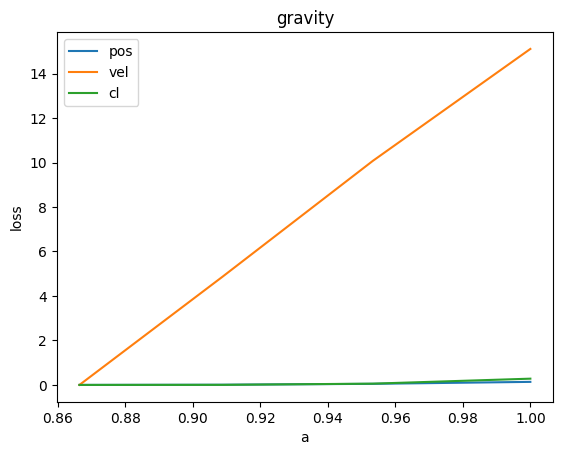

In [22]:
with jax.default_device(jax.devices("cpu")[0]):
    plot_loss_of_scale(og_gas_poss, og_gas_vels, "gravity")#, f"plots/loss_gravity_i={i_snapshots},dt0=0.005")

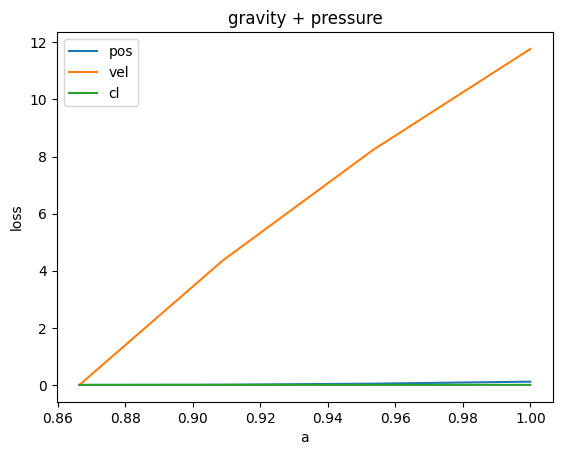

In [23]:
with jax.default_device(jax.devices("cpu")[0]):
    plot_loss_of_scale(nn_gas_poss, nn_gas_vels, "gravity + pressure")#, f"plots/loss_gravity+pressure_i={i_snapshots},dt0=0.005")

In [24]:
particle_loss_fn(untrained_model, architecture)

dark matter and gas
Using learned pressure force
No latent variable
dark matter and gas
Using learned pressure force
No latent variable
dark matter and gas
Using learned pressure force
No latent variable
pos_loss =  0.048507873
vel_loss =  7.4612737
cl_loss =  0.008209772


Array(7.5918794, dtype=float32)

In [25]:
particle_loss_fn(model, architecture)

dark matter and gas
Using learned pressure force
No latent variable
dark matter and gas
Using learned pressure force
No latent variable
dark matter and gas
Using learned pressure force
No latent variable
pos_loss =  0.041680258
vel_loss =  6.0861626
cl_loss =  5.8130117e-05


Array(6.128424, dtype=float32)

In [26]:
1/scales**2

array([1.33218377, 1.21071734, 1.10032602, 1.        ])